In [165]:
import pandas as pd
import numpy as np
import pypsa
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# Configuration

In [166]:
data_dir = Path("../data")
figure_dir = Path("../figures_paper")

mapping_pypsa_carriers = {
    "Combined-Cycle Gas": "Gas",
    "Load shedding": None,
    "Offshore Wind (AC)": "Wind Offshore",
    "Offshore Wind (DC)": "Wind Offshore",
    "Onshore Wind": "Wind Onshore",
    "Open-Cycle Gas": "Gas",
    "Run of River": "Run-of-river",
    "Solar": "Solar",
    "biomass": "Biomass",
    "nuclear": "Nuclear",
    "coal": "Coal",
    "lignite": "Lignite",
    "oil": "Oil",
    "solar-hsat": "Solar",
    "Pumped Hydro Storage": "Pumped Hydro Storage",
    "Reservoir & Dam": "Reservoir & Dam",
}


start_date = (pd.Timestamp("2022-01-01"),)
end_date = (pd.Timestamp("2022-12-31 23:00"),)


country = "DE"

resampling_rule = "W-MON"

x_length = 6

phi = 1.618

data_dir = Path("../data")

n = pypsa.Network(data_dir / "network_files" / "hindcast-dyn-rolling-wy2022.nc")

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network '' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [167]:
# Color mapping for plotting

color_dict = n.carriers["color"].to_dict()

mapping_color = {
    "offwind-ac": "Wind Offshore",
    "offwind-dc": "Wind Offshore",
    "onwind": "Wind Onshore",
    "solar": "Solar",
    "solar-hsat": "Solar",
    "CCGT": "Gas",
    "OCGT": "Gas",
    "PHS": "Pumped Hydro Storage",
    "biomass": "Biomass",
    "coal": "Coal",
    "geothermal": "Geothermal",
    "hydro": "Reservoir & Dam",
    "lignite": "Lignite",
    "nuclear": "Nuclear",
    "oil": "Oil",
    "ror": "Run-of-river",
}

color_dict_new = {}

for original_name, new_name in mapping_color.items():
    # Use the color from the original carrier
    if original_name in color_dict:
        color_dict_new[new_name] = color_dict[original_name]


color_dict_new['Other'] = 'tab:red'
color_dict_new

{'Wind Offshore': '#74c6f2',
 'Wind Onshore': '#235ebc',
 'Solar': '#fdb915',
 'Gas': '#e0986c',
 'Pumped Hydro Storage': '#51dbcc',
 'Biomass': '#baa741',
 'Coal': '#545454',
 'Geothermal': '#ba91b1',
 'Reservoir & Dam': '#298c81',
 'Lignite': '#826837',
 'Nuclear': '#ff8c00',
 'Oil': '#c9c9c9',
 'Run-of-river': '#3dbfb0',
 'Other': 'tab:red'}

# PyPSA generation plot

In [168]:
supply_stats = n.statistics.supply(groupby=["bus", "carrier"], groupby_time=False) / 1000
country_supply = supply_stats.xs(country, level="bus")
country_generators_and_storage = country_supply.loc[["Generator", "StorageUnit"], :]
country_dispatch_raw = country_generators_and_storage.T.droplevel(0, axis=1)

ignored_carriers = [
    col for col, target in mapping_pypsa_carriers.items() if target is None and col in country_dispatch_raw.columns
]
country_dispatch_raw = country_dispatch_raw.drop(columns=ignored_carriers)

carrier_rename = {
    col: target
    for col, target in mapping_pypsa_carriers.items()
    if target is not None and col in country_dispatch_raw.columns
}
country_dispatch = country_dispatch_raw.rename(columns=carrier_rename)
country_dispatch = country_dispatch.T.groupby(level=0).sum().T  # merg


if resampling_rule:
    country_dispatch_res = country_dispatch.resample(resampling_rule).sum()
else:
    country_dispatch_res = country_dispatch

country_dispatch_res.head()

carrier,Biomass,Coal,Gas,Lignite,Oil,Pumped Hydro Storage,Run-of-river,Solar,Wind Offshore,Wind Onshore
snapshot,,,,,,,,,,
2022-01-03,107.616923,713.344829,0.000098,1558.999412,0.000033,0.000007,152.273737,137.631375,488.850090,2406.718628
2022-01-10,251.106171,2994.207117,390.776173,3645.892338,0.000531,79.190784,537.467959,422.621926,918.152925,3545.692323
2022-01-17,251.106197,3038.527392,1160.378443,3645.892789,0.000090,25.409737,518.176176,494.078555,880.405227,2572.561230
2022-01-24,251.106206,3009.455407,1325.257358,3645.892824,0.000000,5.621252,544.699041,511.474738,893.379789,2779.039904
2022-01-31,251.106206,2505.047108,417.526710,3590.652139,0.000000,56.385042,543.074468,518.778823,992.304953,5030.355525


In [169]:
country_dispatch_raw.sum()

carrier
Combined-Cycle Gas        9085.082428
Offshore Wind (AC)       34957.578158
Offshore Wind (DC)           0.000000
Onshore Wind            117076.509692
Open-Cycle Gas               0.000289
Run of River             17282.147624
Solar                    70109.977182
biomass                  13087.722061
coal                    116110.840243
lignite                 181099.672355
oil                       4877.521059
solar-hsat                   0.000000
Pumped Hydro Storage      2673.019136
dtype: float64

In [170]:
country_dispatch.sum()

carrier
Biomass                  13087.722061
Coal                    116110.840243
Gas                       9085.082717
Lignite                 181099.672355
Oil                       4877.521059
Pumped Hydro Storage      2673.019136
Run-of-river             17282.147624
Solar                    70109.977182
Wind Offshore            34957.578158
Wind Onshore            117076.509692
dtype: float64

In [171]:
country_dispatch_res.index

DatetimeIndex(['2022-01-03', '2022-01-10', '2022-01-17', '2022-01-24',
               '2022-01-31', '2022-02-07', '2022-02-14', '2022-02-21',
               '2022-02-28', '2022-03-07', '2022-03-14', '2022-03-21',
               '2022-03-28', '2022-04-04', '2022-04-11', '2022-04-18',
               '2022-04-25', '2022-05-02', '2022-05-09', '2022-05-16',
               '2022-05-23', '2022-05-30', '2022-06-06', '2022-06-13',
               '2022-06-20', '2022-06-27', '2022-07-04', '2022-07-11',
               '2022-07-18', '2022-07-25', '2022-08-01', '2022-08-08',
               '2022-08-15', '2022-08-22', '2022-08-29', '2022-09-05',
               '2022-09-12', '2022-09-19', '2022-09-26', '2022-10-03',
               '2022-10-10', '2022-10-17', '2022-10-24', '2022-10-31',
               '2022-11-07', '2022-11-14', '2022-11-21', '2022-11-28',
               '2022-12-05', '2022-12-12', '2022-12-19', '2022-12-26',
               '2023-01-02'],
              dtype='datetime64[ns]', name='sna

In [172]:
country_dispatch.sum()

carrier
Biomass                  13087.722061
Coal                    116110.840243
Gas                       9085.082717
Lignite                 181099.672355
Oil                       4877.521059
Pumped Hydro Storage      2673.019136
Run-of-river             17282.147624
Solar                    70109.977182
Wind Offshore            34957.578158
Wind Onshore            117076.509692
dtype: float64

# ENTSOE

In [173]:
entsoe_raw = pd.read_csv(
    data_dir / "generation" / f"generation_{country}_hourly_data.csv",
    index_col=0,
    parse_dates=True,
)

entsoe_filtered_raw = entsoe_raw[pd.Timestamp(start_date[0], tz="UTC") : pd.Timestamp(end_date[0], tz="UTC")]

entsoe_filtered_raw.head()

,"('Biomass', 'Actual Aggregated')","('Fossil Brown coal/Lignite', 'Actual Aggregated')","('Fossil Coal-derived gas', 'Actual Aggregated')","('Fossil Gas', 'Actual Aggregated')","('Fossil Gas', 'Actual Consumption')","('Fossil Hard coal', 'Actual Aggregated')","('Fossil Oil', 'Actual Aggregated')","('Fossil Oil', 'Actual Consumption')","('Geothermal', 'Actual Aggregated')","('Hydro Pumped Storage', 'Actual Aggregated')",...,"('Other', 'Actual Aggregated')","('Other renewable', 'Actual Aggregated')","('Other renewable', 'Actual Consumption')","('Solar', 'Actual Aggregated')","('Solar', 'Actual Consumption')","('Waste', 'Actual Aggregated')","('Wind Offshore', 'Actual Aggregated')","('Wind Onshore', 'Actual Aggregated')","('Wind Onshore', 'Actual Consumption')",Biomass
2022-01-01 00:00:00+00:00,4253.333333,3540.666667,NaN,3414.333333,NaN,2048.666667,279.0,NaN,26.0,402.00,...,333.0,132.0,NaN,2.0,0.0,851.333333,5804.333333,24166.00,0.0,NaN
2022-01-01 01:00:00+00:00,4258.000000,3495.000000,NaN,3408.750000,NaN,2033.250000,279.0,NaN,26.0,379.75,...,333.0,133.0,NaN,2.0,0.0,845.250000,5548.000000,23188.75,0.0,NaN
2022-01-01 02:00:00+00:00,4263.000000,3504.750000,NaN,3414.000000,NaN,2023.750000,279.0,NaN,27.0,321.25,...,333.0,132.5,NaN,2.0,0.0,841.750000,5382.750000,22113.50,0.0,NaN
2022-01-01 03:00:00+00:00,4267.250000,3537.500000,NaN,3428.750000,NaN,2013.250000,279.0,NaN,27.0,244.25,...,333.0,131.5,NaN,2.0,0.0,835.500000,5586.500000,20620.75,0.0,NaN
2022-01-01 04:00:00+00:00,4280.250000,3767.000000,NaN,3421.250000,NaN,2014.000000,279.0,NaN,27.0,212.75,...,333.0,131.5,NaN,2.0,0.0,841.750000,4531.250000,19587.75,0.0,NaN


In [174]:
entsoe_filtered_raw.columns

Index(['('Biomass', 'Actual Aggregated')',
       '('Fossil Brown coal/Lignite', 'Actual Aggregated')',
       '('Fossil Coal-derived gas', 'Actual Aggregated')',
       '('Fossil Gas', 'Actual Aggregated')',
       '('Fossil Gas', 'Actual Consumption')',
       '('Fossil Hard coal', 'Actual Aggregated')',
       '('Fossil Oil', 'Actual Aggregated')',
       '('Fossil Oil', 'Actual Consumption')',
       '('Geothermal', 'Actual Aggregated')',
       '('Hydro Pumped Storage', 'Actual Aggregated')',
       '('Hydro Pumped Storage', 'Actual Consumption')',
       '('Hydro Run-of-river and poundage', 'Actual Aggregated')',
       '('Hydro Water Reservoir', 'Actual Aggregated')',
       '('Hydro Water Reservoir', 'Actual Consumption')',
       '('Nuclear', 'Actual Aggregated')', '('Nuclear', 'Actual Consumption')',
       '('Other', 'Actual Aggregated')',
       '('Other renewable', 'Actual Aggregated')',
       '('Other renewable', 'Actual Consumption')',
       '('Solar', 'Actual Aggregat

In [175]:
entsoe_filtered_raw.sum()

('Biomass', 'Actual Aggregated')                            3.802634e+07
('Fossil Brown coal/Lignite', 'Actual Aggregated')          1.035259e+08
('Fossil Coal-derived gas', 'Actual Aggregated')            6.512500e+02
('Fossil Gas', 'Actual Aggregated')                         4.591159e+07
('Fossil Gas', 'Actual Consumption')                        0.000000e+00
('Fossil Hard coal', 'Actual Aggregated')                   6.289539e+07
('Fossil Oil', 'Actual Aggregated')                         2.788978e+06
('Fossil Oil', 'Actual Consumption')                        0.000000e+00
('Geothermal', 'Actual Aggregated')                         2.032400e+05
('Hydro Pumped Storage', 'Actual Aggregated')               1.015594e+07
('Hydro Pumped Storage', 'Actual Consumption')              1.359417e+07
('Hydro Run-of-river and poundage', 'Actual Aggregated')    1.130533e+07
('Hydro Water Reservoir', 'Actual Aggregated')              1.556329e+06
('Hydro Water Reservoir', 'Actual Consumption')    

In [176]:
keep_cols = [
    "('Biomass', 'Actual Aggregated')",
    "('Fossil Brown coal/Lignite', 'Actual Aggregated')",
    #"('Fossil Coal-derived gas', 'Actual Aggregated')",
    "('Fossil Gas', 'Actual Aggregated')",
    "('Fossil Hard coal', 'Actual Aggregated')",
    "('Fossil Oil', 'Actual Aggregated')",
    "('Geothermal', 'Actual Aggregated')",
    "('Hydro Pumped Storage', 'Actual Aggregated')",
    #"('Hydro Pumped Storage', 'Actual Consumption')",
    "('Hydro Run-of-river and poundage', 'Actual Aggregated')",
    "('Hydro Water Reservoir', 'Actual Aggregated')",
    "('Nuclear', 'Actual Aggregated')",
    "('Other', 'Actual Aggregated')",
    "('Other renewable', 'Actual Aggregated')",
    "('Solar', 'Actual Aggregated')",
    "('Waste', 'Actual Aggregated')",
    "('Wind Offshore', 'Actual Aggregated')",
    "('Wind Onshore', 'Actual Aggregated')",
]
entsoe_filtered = entsoe_filtered_raw[keep_cols].copy()

mapping_entsoe_pypsa = {
    "('Biomass', 'Actual Aggregated')": "Biomass",
    "('Fossil Brown coal/Lignite', 'Actual Aggregated')": "Lignite",
    "('Fossil Coal-derived gas', 'Actual Aggregated')": "Gas",
    "('Fossil Gas', 'Actual Aggregated')": "Gas",
    "('Fossil Hard coal', 'Actual Aggregated')": "Coal",
    "('Fossil Oil', 'Actual Aggregated')": "Oil",
    "('Geothermal', 'Actual Aggregated')": "Geothermal",
    "('Hydro Pumped Storage', 'Actual Aggregated')": "Pumped Hydro Storage",
    #"('Hydro Pumped Storage', 'Actual Consumption')": ,
    "('Hydro Run-of-river and poundage', 'Actual Aggregated')": "Run-of-river",
    "('Hydro Water Reservoir', 'Actual Aggregated')": "Reservoir & Dam",
    "('Nuclear', 'Actual Aggregated')": "Nuclear",
    "('Other', 'Actual Aggregated')": "Other",
    "('Other renewable', 'Actual Aggregated')": "Other",
    "('Solar', 'Actual Aggregated')": "Solar",
    "('Waste', 'Actual Aggregated')": "Biomass",
    "('Wind Offshore', 'Actual Aggregated')": "Wind Offshore",
    "('Wind Onshore', 'Actual Aggregated')": "Wind Onshore",
}

entsoe_filtered.sum()

('Biomass', 'Actual Aggregated')                            3.802634e+07
('Fossil Brown coal/Lignite', 'Actual Aggregated')          1.035259e+08
('Fossil Gas', 'Actual Aggregated')                         4.591159e+07
('Fossil Hard coal', 'Actual Aggregated')                   6.289539e+07
('Fossil Oil', 'Actual Aggregated')                         2.788978e+06
('Geothermal', 'Actual Aggregated')                         2.032400e+05
('Hydro Pumped Storage', 'Actual Aggregated')               1.015594e+07
('Hydro Run-of-river and poundage', 'Actual Aggregated')    1.130533e+07
('Hydro Water Reservoir', 'Actual Aggregated')              1.556329e+06
('Nuclear', 'Actual Aggregated')                            3.282362e+07
('Other', 'Actual Aggregated')                              2.303491e+06
('Other renewable', 'Actual Aggregated')                    1.087412e+06
('Solar', 'Actual Aggregated')                              5.598763e+07
('Waste', 'Actual Aggregated')                     

In [177]:
entsoe_clean = entsoe_filtered.rename(columns=mapping_entsoe_pypsa) /1000
entsoe_clean.columns

Index(['Biomass', 'Lignite', 'Gas', 'Coal', 'Oil', 'Geothermal',
       'Pumped Hydro Storage', 'Run-of-river', 'Reservoir & Dam', 'Nuclear',
       'Other', 'Other', 'Solar', 'Biomass', 'Wind Offshore', 'Wind Onshore'],
      dtype='str')

In [178]:
entsoe_clean = entsoe_clean.tz_localize(None)
entsoe_clean.index

DatetimeIndex(['2022-01-01 00:00:00', '2022-01-01 01:00:00',
               '2022-01-01 02:00:00', '2022-01-01 03:00:00',
               '2022-01-01 04:00:00', '2022-01-01 05:00:00',
               '2022-01-01 06:00:00', '2022-01-01 07:00:00',
               '2022-01-01 08:00:00', '2022-01-01 09:00:00',
               ...
               '2022-12-31 14:00:00', '2022-12-31 15:00:00',
               '2022-12-31 16:00:00', '2022-12-31 17:00:00',
               '2022-12-31 18:00:00', '2022-12-31 19:00:00',
               '2022-12-31 20:00:00', '2022-12-31 21:00:00',
               '2022-12-31 22:00:00', '2022-12-31 23:00:00'],
              dtype='datetime64[us]', length=8760, freq=None)

In [179]:
entsoe_clean.head()

,Biomass,Lignite,Gas,Coal,Oil,Geothermal,Pumped Hydro Storage,Run-of-river,Reservoir & Dam,Nuclear,Other,Other,Solar,Biomass,Wind Offshore,Wind Onshore
2022-01-01 00:00:00,4.253333,3.540667,3.414333,2.048667,0.279,0.026,0.40200,1.429333,0.088667,3.34700,0.333,0.1320,0.002,0.851333,5.804333,24.16600
2022-01-01 01:00:00,4.258000,3.495000,3.408750,2.033250,0.279,0.026,0.37975,1.428250,0.046750,3.34425,0.333,0.1330,0.002,0.845250,5.548000,23.18875
2022-01-01 02:00:00,4.263000,3.504750,3.414000,2.023750,0.279,0.027,0.32125,1.428250,0.031500,3.34250,0.333,0.1325,0.002,0.841750,5.382750,22.11350
2022-01-01 03:00:00,4.267250,3.537500,3.428750,2.013250,0.279,0.027,0.24425,1.426500,0.078500,3.34250,0.333,0.1315,0.002,0.835500,5.586500,20.62075
2022-01-01 04:00:00,4.280250,3.767000,3.421250,2.014000,0.279,0.027,0.21275,1.419750,0.065750,3.34725,0.333,0.1315,0.002,0.841750,4.531250,19.58775


In [180]:
entsoe_clean = entsoe_clean.T.groupby(level=0).sum().T
entsoe_clean.head()

,Biomass,Coal,Gas,Geothermal,Lignite,Nuclear,Oil,Other,Pumped Hydro Storage,Reservoir & Dam,Run-of-river,Solar,Wind Offshore,Wind Onshore
2022-01-01 00:00:00,5.104667,2.048667,3.414333,0.026,3.540667,3.34700,0.279,0.4650,0.40200,0.088667,1.429333,0.002,5.804333,24.16600
2022-01-01 01:00:00,5.103250,2.033250,3.408750,0.026,3.495000,3.34425,0.279,0.4660,0.37975,0.046750,1.428250,0.002,5.548000,23.18875
2022-01-01 02:00:00,5.104750,2.023750,3.414000,0.027,3.504750,3.34250,0.279,0.4655,0.32125,0.031500,1.428250,0.002,5.382750,22.11350
2022-01-01 03:00:00,5.102750,2.013250,3.428750,0.027,3.537500,3.34250,0.279,0.4645,0.24425,0.078500,1.426500,0.002,5.586500,20.62075
2022-01-01 04:00:00,5.122000,2.014000,3.421250,0.027,3.767000,3.34725,0.279,0.4645,0.21275,0.065750,1.419750,0.002,4.531250,19.58775


In [181]:
country_dispatch.head()

carrier,Biomass,Coal,Gas,Lignite,Oil,Pumped Hydro Storage,Run-of-river,Solar,Wind Offshore,Wind Onshore
snapshot,,,,,,,,,,
2022-01-01 00:00:00,1.494679,2.983221,0.000001,21.701725,4.200000e-07,0.0,1.983777,0.0,7.274165,31.141554
2022-01-01 01:00:00,1.494679,2.374967,0.000001,21.701725,4.200000e-07,0.0,1.986250,0.0,7.273035,29.902186
2022-01-01 02:00:00,1.494679,1.085640,0.000001,21.701725,4.200000e-07,0.0,1.987468,0.0,7.263835,27.970121
2022-01-01 03:00:00,1.494679,0.852143,0.000001,21.701725,4.200000e-07,0.0,1.989162,0.0,7.268342,27.042196
2022-01-01 04:00:00,1.494679,2.344034,0.000001,21.701725,4.200000e-07,0.0,1.990312,0.0,7.273154,25.151336


In [182]:
unique_cols = list(dict.fromkeys(entsoe_clean.columns.tolist()))
clean_data = {col: entsoe_clean[[col]].sum(axis=1) for col in unique_cols}
entsoe_dedup = pd.DataFrame(clean_data, index=entsoe_clean.index)

diff = entsoe_dedup.copy()
for col in diff.columns:
    if col in country_dispatch.columns:
        diff[col] = entsoe_dedup[col] - country_dispatch[col]
    # else: leave as entsoe value untouched

diff.head()

,Biomass,Coal,Gas,Geothermal,Lignite,Nuclear,Oil,Other,Pumped Hydro Storage,Reservoir & Dam,Run-of-river,Solar,Wind Offshore,Wind Onshore
2022-01-01 00:00:00,3.609987,-0.934554,3.414332,0.026,-18.161059,3.34700,0.279,0.4650,0.40200,0.088667,-0.554444,0.002,-1.469831,-6.975554
2022-01-01 01:00:00,3.608571,-0.341717,3.408749,0.026,-18.206725,3.34425,0.279,0.4660,0.37975,0.046750,-0.558000,0.002,-1.725035,-6.713436
2022-01-01 02:00:00,3.610071,0.938110,3.413999,0.027,-18.196975,3.34250,0.279,0.4655,0.32125,0.031500,-0.559218,0.002,-1.881085,-5.856621
2022-01-01 03:00:00,3.608071,1.161107,3.428749,0.027,-18.164225,3.34250,0.279,0.4645,0.24425,0.078500,-0.562662,0.002,-1.681842,-6.421446
2022-01-01 04:00:00,3.627321,-0.330034,3.421249,0.027,-17.934725,3.34725,0.279,0.4645,0.21275,0.065750,-0.570562,0.002,-2.741904,-5.563586


In [183]:
diff_res = diff.resample(resampling_rule).sum()

In [184]:
diff

,Biomass,Coal,Gas,Geothermal,Lignite,Nuclear,Oil,Other,Pumped Hydro Storage,Reservoir & Dam,Run-of-river,Solar,Wind Offshore,Wind Onshore
2022-01-01 00:00:00,3.609987,-0.934554,3.414332,0.02600,-18.161059,3.34700,0.2790,0.46500,0.40200,0.088667,-0.554444,0.00200,-1.469831,-6.975554
2022-01-01 01:00:00,3.608571,-0.341717,3.408749,0.02600,-18.206725,3.34425,0.2790,0.46600,0.37975,0.046750,-0.558000,0.00200,-1.725035,-6.713436
2022-01-01 02:00:00,3.610071,0.938110,3.413999,0.02700,-18.196975,3.34250,0.2790,0.46550,0.32125,0.031500,-0.559218,0.00200,-1.881085,-5.856621
2022-01-01 03:00:00,3.608071,1.161107,3.428749,0.02700,-18.164225,3.34250,0.2790,0.46450,0.24425,0.078500,-0.562662,0.00200,-1.681842,-6.421446
2022-01-01 04:00:00,3.627321,-0.330034,3.421249,0.02700,-17.934725,3.34725,0.2790,0.46450,0.21275,0.065750,-0.570562,0.00200,-2.741904,-5.563586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-31 19:00:00,3.615570,2.197000,2.150250,0.02400,-0.613635,3.40000,0.3040,0.28575,0.48350,0.043500,-0.201243,0.00400,-2.973976,-17.674890
2022-12-31 20:00:00,3.496570,2.217500,2.153000,0.02400,2.379894,3.40200,0.2955,0.28550,0.40250,0.017500,-0.207543,0.00325,-3.104049,-17.535671
2022-12-31 21:00:00,3.426820,2.216750,2.153250,0.02425,3.760500,3.24375,0.2995,0.28600,0.32975,0.023000,-0.212628,0.00400,-3.390196,-19.014458
2022-12-31 22:00:00,3.396070,2.202500,2.123750,0.02500,3.814750,2.66950,0.3015,0.28500,0.20425,0.035500,-0.219348,0.00325,-3.931436,-19.043762


# Get prices

In [185]:
prices_dict = {}


sim_labels = {'hindcast-std',
              'hindcast-dyn',
              'hindcast-dyn-rolling'}
# Load simulation
for sim_label in sim_labels:
    file_dir = Path('../results_concat') / sim_label / 'electricity_prices' / "combined_electricity_prices.csv"

    df_sim = pd.read_csv(file_dir, index_col=0, parse_dates=True)
    df_sim = df_sim[df_sim.index.year.isin([2022])]

    prices_dict[sim_label] = df_sim

# Load benchmark
benchmark_path = data_dir / "benchmark" / "electricity_prices.csv"
df_bench = pd.read_csv(benchmark_path, index_col=0, parse_dates=True)

if df_bench.index.tz is None:
     df_bench.index = df_bench.index.tz_localize("UTC")
else:
    df_bench.index = df_bench.index.tz_convert("UTC")

df_bench = df_bench.interpolate().ffill().bfill()

df_bench = df_bench[df_bench.index.year.isin([2022])]

prices_dict["benchmark"] = df_bench
prices_dict

{'hindcast-dyn':                              AL          AT          BA          BE  \
 snapshot                                                              
 2022-01-01 00:00:00  164.710562  156.743834  156.359288  140.594888   
 2022-01-01 01:00:00  164.044772  156.743817  155.326374  135.257340   
 2022-01-01 02:00:00  160.889974  156.319970  154.661043  135.515949   
 2022-01-01 03:00:00  162.030591  156.168618  155.514276  136.505556   
 2022-01-01 04:00:00  162.458917  155.977500  155.305447  136.342516   
 ...                         ...         ...         ...         ...   
 2022-12-31 19:00:00  176.888374  173.741522  173.747036  160.907923   
 2022-12-31 20:00:00  173.835032  173.621355  173.353067  151.599910   
 2022-12-31 21:00:00  173.539161  173.657354  173.436281  151.599926   
 2022-12-31 22:00:00  173.534268  173.207571  172.289738  151.599796   
 2022-12-31 23:00:00  173.529857  172.588008  172.289721  151.599744   
 
                              BG          CH  

# That one plot

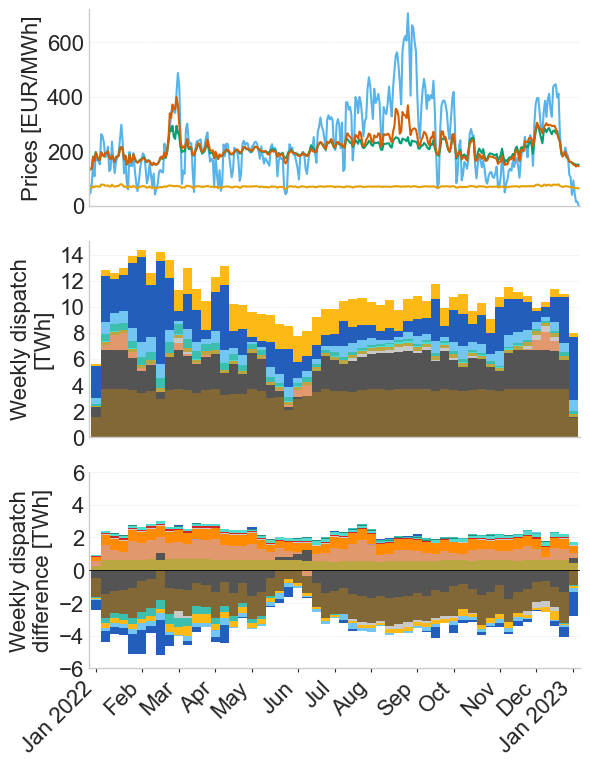

In [186]:
import matplotlib as mpl
# ── Figure ─────────────────────────────────────────────────────────────────────
phi = 1.618
fig, axs = plt.subplots(
    ncols=1,
    nrows=3,
    figsize=(x_length, x_length * phi * 0.8),
    sharex=False,
)

# ── Global style (mirrors setup_style) ────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams["axes.spines.right"]   = False
mpl.rcParams["axes.spines.top"]     = False
plt.rcParams["font.family"]         = "Arial"
plt.rcParams["axes.titleweight"]    = "bold"
plt.rcParams["axes.labelsize"]      = 16
plt.rcParams["xtick.labelsize"]     = 16
plt.rcParams["ytick.labelsize"]     = 16
plt.rcParams["legend.fontsize"]     = 16
plt.rcParams["legend.title_fontsize"] = 16

# ── ax[0] : Prices ─────────────────────────────────────────────────────────────
plot_order = [
    "benchmark",
    "hindcast-std",
    "hindcast-dyn",
    "hindcast-dyn-rolling",
]

sim_color = {
    "benchmark":            "#56b4e9",
    "hindcast-dyn":         "#009e73",
    "hindcast-dyn-rolling": "#d55e00",
    "hindcast-std":         "#e69f00",
}

for label in plot_order:
    if label not in prices_dict:
        continue
    df = prices_dict[label]
    if country not in df.columns:
        continue
    series = df[country]
    if resampling_rule:
        series = series.resample("D").mean()
    axs[0].plot(series, label=label, color=sim_color.get(label, None))

axs[0].set_xlim(left=start_date, right=end_date)
axs[0].set_ylim(bottom=0, top=720)
axs[0].set_ylabel("Prices [EUR/MWh]")
axs[0].yaxis.grid(True, linestyle="dashed", linewidth=0.5, alpha=0.4, zorder=0)
axs[0].xaxis.grid(False)
axs[0].set_axisbelow(True)
axs[0].set_xticks([])
axs[0].tick_params(axis="y", which="both", left=False)

# ── ax[1] : Dispatch ───────────────────────────────────────────────────────────
carrier_order = [
    "Lignite",
    "Coal",
    "Gas",
    "Oil",
    "Biomass",
    "Pumped Hydro Storage",
    "Run-of-river",
    "Wind Offshore",
    "Wind Onshore",
    "Solar",
]

def reorder_columns(df, order):
    existing  = [c for c in order if c in df.columns]
    remaining = [c for c in df.columns if c not in existing]
    return df[existing + remaining]

country_dispatch_res_twh = reorder_columns(country_dispatch_res, carrier_order) / 1000
country_dispatch_res_twh.plot.bar(
    stacked=True, width=1.0, ax=axs[1], legend=False,
    color=color_dict_new,
)
axs[1].set_ylabel("Weekly dispatch\n[TWh]")
axs[1].set_xlabel("")
axs[1].yaxis.grid(True, linestyle="dashed", linewidth=0.5, alpha=0.4, zorder=0)
axs[1].xaxis.grid(False)
axs[1].set_axisbelow(True)
axs[1].set_xticks([])
axs[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(2))
axs[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
axs[1].tick_params(axis="y", which="both", left=False)

# ── ax[2] : Dispatch difference ────────────────────────────────────────────────
diff_res_plot = diff_res.copy() / 1000
diff_timestamps = diff_res_plot.index
diff_res_plot = diff_res_plot.reset_index(drop=True)

diff_res_plot.plot.bar(
    stacked=True, width=1.0, ax=axs[2], legend=False,
    color=color_dict_new,
)
axs[2].set_xlabel("")
axs[2].set_ylabel("Weekly dispatch\ndifference [TWh]")
axs[2].yaxis.grid(True, linestyle="dashed", linewidth=0.5, alpha=0.4, zorder=0)
axs[2].xaxis.grid(False)
axs[2].set_axisbelow(True)
axs[2].set_ylim(bottom=-6, top=6)
axs[2].yaxis.set_major_locator(mpl.ticker.MultipleLocator(2))
axs[2].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
axs[2].tick_params(axis="y", which="both", left=False)
axs[2].axhline(0, color="black", linewidth=0.6, zorder=3)

# Monthly ticks
tick_positions = []
tick_labels    = []
prev_month     = None
for i, ts in enumerate(diff_timestamps):
    if ts.month != prev_month:
        tick_positions.append(i)
        tick_labels.append(
            ts.strftime("%b %Y") if (ts.month == 1 or prev_month is None)
            else ts.strftime("%b")
        )
        prev_month = ts.month
axs[2].set_xticks(tick_positions)
axs[2].set_xticklabels(tick_labels, rotation=45, ha="right")
axs[2].tick_params(axis="x", length=3)

# ── Shared spine cleanup ────────────────────────────────────────────────────────
for ax in axs:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


plt.tight_layout()
# Save the figure
file_path = figure_dir / "price_dispatch_comparison_DE.pdf"
plt.savefig(file_path, bbox_inches="tight")
plt.show()

/var/folders/bp/wwf437ks68j7y4307x_22ryw0000z9/T/ipykernel_26314/2877832758.py:26: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



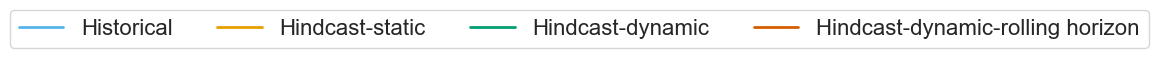

/var/folders/bp/wwf437ks68j7y4307x_22ryw0000z9/T/ipykernel_26314/2877832758.py:56: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



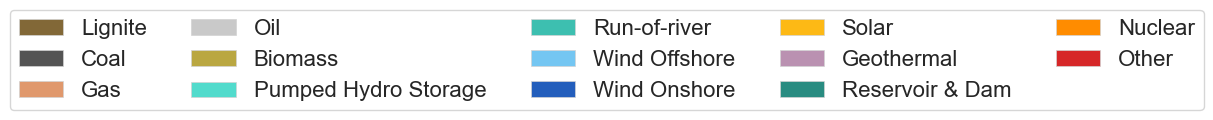

In [187]:
# ── Price legend figure ────────────────────────────────────────────────────────
legend_label_map = {
    "benchmark":            "Historical",
    "hindcast-std":         "Hindcast-static",
    "hindcast-dyn":         "Hindcast-dynamic",
    "hindcast-dyn-rolling": "Hindcast-dynamic-rolling horizon",
}
desired_order = ["benchmark", "hindcast-std", "hindcast-dyn", "hindcast-dyn-rolling"]

fig_leg1, ax_leg1 = plt.subplots(figsize=(x_length, 0.5))
ax_leg1.set_axis_off()

dummy_handles = [
    mpl.lines.Line2D([0], [0], color=sim_color[k], linewidth=2)
    for k in desired_order if k in sim_color
]
dummy_labels = [legend_label_map[k] for k in desired_order if k in sim_color]

ax_leg1.legend(
    dummy_handles, dummy_labels,
    loc="center",
    ncol=4,
    frameon=True,
    fancybox=True,
)
plt.tight_layout()
fig_leg1.savefig(figure_dir / "legend_prices.pdf", bbox_inches="tight")
plt.show()

# ── Carrier legend figure ──────────────────────────────────────────────────────
# Build handles from color_dict_new, respecting carrier_order + any extras
carrier_order = [
    "Lignite", "Coal", "Gas", "Oil", "Biomass",
    "Pumped Hydro Storage", "Run-of-river",
    "Wind Offshore", "Wind Onshore", "Solar",
]
all_carriers = [c for c in carrier_order if c in color_dict_new]
extras       = [c for c in color_dict_new if c not in all_carriers]
all_carriers += extras

carrier_handles = [
    mpl.patches.Patch(facecolor=color_dict_new[c], edgecolor="lightgrey", linewidth=0.5)
    for c in all_carriers
]

fig_leg2, ax_leg2 = plt.subplots(figsize=(x_length, 1.0))
ax_leg2.set_axis_off()

ax_leg2.legend(
    carrier_handles, all_carriers,
    loc="center",
    ncol=5,
    frameon=True,
    fancybox=True,
)
plt.tight_layout()
fig_leg2.savefig(figure_dir / "legend_carriers.pdf", bbox_inches="tight")
plt.show()

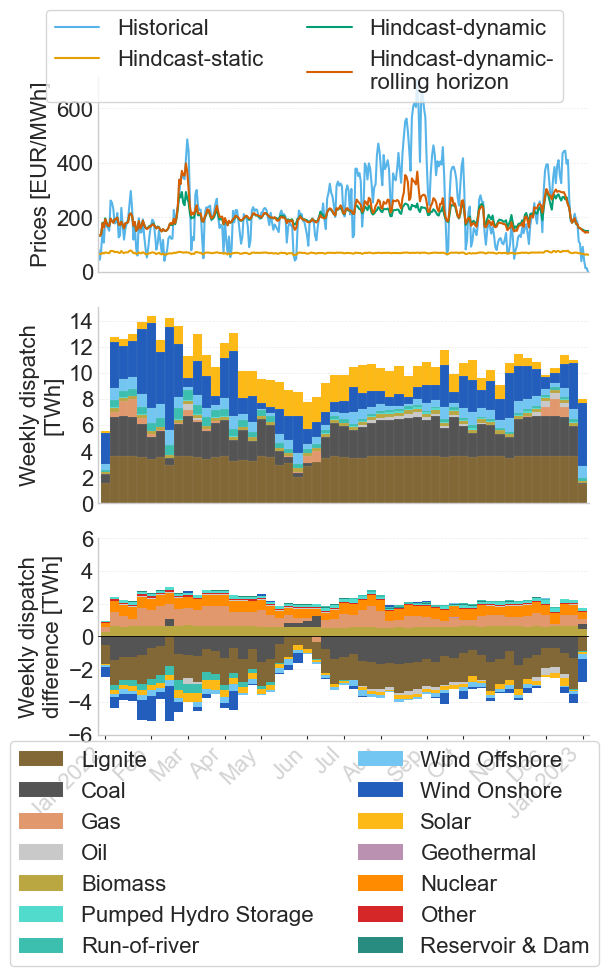

In [188]:
# ── Figure ─────────────────────────────────────────────────────────────────────
phi = 1.618
fig, axs = plt.subplots(
    ncols=1,
    nrows=3,
    figsize=(x_length, x_length * phi * 0.8),
    sharex=False,
)

# ── ax[0] : Prices ─────────────────────────────────────────────────────────────
plot_order = [
    "benchmark",
    "hindcast-std",
    "hindcast-dyn",
    "hindcast-dyn-rolling",
]

for label in plot_order:
    if label not in prices_dict:
        continue
    df = prices_dict[label]
    if country not in df.columns:
        continue
    series = df[country]
    if resampling_rule:
        series = series.resample("D").mean()
    axs[0].plot(series, label=label, color=sim_color.get(label, None))

# ── Price legend ABOVE the figure ──────────────────────────────────────────────
legend_label_map = {
    "benchmark":            "Historical",
    "hindcast-std":         "Hindcast-static",
    "hindcast-dyn":         "Hindcast-dynamic",
    "hindcast-dyn-rolling": "Hindcast-dynamic-\nrolling horizon",
}
desired_order   = ["benchmark", "hindcast-std", "hindcast-dyn", "hindcast-dyn-rolling"]
handles, labels = axs[0].get_legend_handles_labels()
handle_map      = dict(zip(labels, handles))
ordered_handles = [handle_map[k] for k in desired_order if k in handle_map]
ordered_labels  = [legend_label_map.get(k, k) for k in desired_order if k in handle_map]
fig.legend(
    ordered_handles, ordered_labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.08),
    frameon=True,
    fancybox=True,
)

axs[0].set_xlim(left=start_date, right=end_date)
axs[0].set_ylim(bottom=0, top=720)
axs[0].set_ylabel("Prices [EUR/MWh]")
axs[0].yaxis.grid(True, linestyle="dashed", linewidth=0.5, alpha=0.4, zorder=0)
axs[0].xaxis.grid(False)
axs[0].set_axisbelow(True)
axs[0].set_xticks([])
axs[0].tick_params(axis="y", which="both", left=False)

# ── ax[1] : Dispatch ───────────────────────────────────────────────────────────
carrier_order = [
    "Lignite",
    "Nuclear",
    "Coal",
    "Gas",
    "Oil",
    "Biomass",
    "Reservoir & Dam",
    "Pumped Hydro Storage",
    "Run-of-river",
    "Wind Offshore",
    "Wind Onshore",
    "Solar",
]

def reorder_columns(df, order):
    existing  = [c for c in order if c in df.columns]
    remaining = [c for c in df.columns if c not in existing]
    return df[existing + remaining]

country_dispatch_res_twh = reorder_columns(country_dispatch_res, carrier_order) / 1000
country_dispatch_res_twh.plot.bar(
    stacked=True, width=1.0, ax=axs[1], legend=False,
    color=color_dict_new,
    edgecolor="lightgrey", linewidth=0.05,
)
axs[1].set_ylabel("Weekly dispatch\n[TWh]")
axs[1].set_xlabel("")
axs[1].yaxis.grid(True, linestyle="dashed", linewidth=0.5, alpha=0.4, zorder=0)
axs[1].xaxis.grid(False)
axs[1].set_axisbelow(True)
axs[1].set_xticks([])
axs[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(2))
axs[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
axs[1].tick_params(axis="y", which="both", left=False)

# ── ax[2] : Dispatch difference ────────────────────────────────────────────────
diff_res_plot = diff_res.copy() / 1000
diff_timestamps = diff_res_plot.index
diff_res_plot = diff_res_plot.reset_index(drop=True)

diff_res_plot.plot.bar(
    stacked=True, width=1.0, ax=axs[2], legend=False,
    color=color_dict_new,
)
axs[2].set_xlabel("")
axs[2].set_ylabel("Weekly dispatch\ndifference [TWh]")
axs[2].yaxis.grid(True, linestyle="dashed", linewidth=0.5, alpha=0.4, zorder=0)
axs[2].xaxis.grid(False)
axs[2].set_axisbelow(True)
axs[2].set_ylim(bottom=-6, top=6)
axs[2].yaxis.set_major_locator(mpl.ticker.MultipleLocator(2))
axs[2].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
axs[2].tick_params(axis="y", which="both", left=False)
axs[2].axhline(0, color="black", linewidth=0.6, zorder=3)

# Monthly ticks
tick_positions = []
tick_labels    = []
prev_month     = None
for i, ts in enumerate(diff_timestamps):
    if ts.month != prev_month:
        tick_positions.append(i)
        tick_labels.append(
            ts.strftime("%b %Y") if (ts.month == 1 or prev_month is None)
            else ts.strftime("%b")
        )
        prev_month = ts.month
axs[2].set_xticks(tick_positions)
axs[2].set_xticklabels(tick_labels, rotation=45, ha="right")
axs[2].tick_params(axis="x", length=3)

# ── Carrier legend BELOW the figure ────────────────────────────────────────────
# Collect handles from both ax[1] and ax[2], deduplicated by label
h1, l1 = axs[1].get_legend_handles_labels()
h2, l2 = axs[2].get_legend_handles_labels()
seen = {}
for h, l in zip(h1 + h2, l1 + l2):
    if l not in seen:
        seen[l] = h
carrier_handles = list(seen.values())
carrier_labels  = list(seen.keys())

fig.legend(
    carrier_handles, carrier_labels,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, -0.18),
    frameon=True,
    fancybox=True,
)

# ── Shared spine cleanup ────────────────────────────────────────────────────────
for ax in axs:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
# Define path to save figure
# save_path = figure_dir / "price_dispatch_comparison_DE.pdf"
# fig.savefig(save_path, bbox_inches="tight")
plt.show()

In [189]:
print("diff_res shape:", diff_res.shape)
print("diff_res index:", diff_res.index.tolist())

diff_res shape: (53, 14)
diff_res index: [Timestamp('2022-01-03 00:00:00'), Timestamp('2022-01-10 00:00:00'), Timestamp('2022-01-17 00:00:00'), Timestamp('2022-01-24 00:00:00'), Timestamp('2022-01-31 00:00:00'), Timestamp('2022-02-07 00:00:00'), Timestamp('2022-02-14 00:00:00'), Timestamp('2022-02-21 00:00:00'), Timestamp('2022-02-28 00:00:00'), Timestamp('2022-03-07 00:00:00'), Timestamp('2022-03-14 00:00:00'), Timestamp('2022-03-21 00:00:00'), Timestamp('2022-03-28 00:00:00'), Timestamp('2022-04-04 00:00:00'), Timestamp('2022-04-11 00:00:00'), Timestamp('2022-04-18 00:00:00'), Timestamp('2022-04-25 00:00:00'), Timestamp('2022-05-02 00:00:00'), Timestamp('2022-05-09 00:00:00'), Timestamp('2022-05-16 00:00:00'), Timestamp('2022-05-23 00:00:00'), Timestamp('2022-05-30 00:00:00'), Timestamp('2022-06-06 00:00:00'), Timestamp('2022-06-13 00:00:00'), Timestamp('2022-06-20 00:00:00'), Timestamp('2022-06-27 00:00:00'), Timestamp('2022-07-04 00:00:00'), Timestamp('2022-07-11 00:00:00'), Timest

In [190]:
country_dispatch.index

DatetimeIndex(['2022-01-01 00:00:00', '2022-01-01 01:00:00',
               '2022-01-01 02:00:00', '2022-01-01 03:00:00',
               '2022-01-01 04:00:00', '2022-01-01 05:00:00',
               '2022-01-01 06:00:00', '2022-01-01 07:00:00',
               '2022-01-01 08:00:00', '2022-01-01 09:00:00',
               ...
               '2022-12-31 14:00:00', '2022-12-31 15:00:00',
               '2022-12-31 16:00:00', '2022-12-31 17:00:00',
               '2022-12-31 18:00:00', '2022-12-31 19:00:00',
               '2022-12-31 20:00:00', '2022-12-31 21:00:00',
               '2022-12-31 22:00:00', '2022-12-31 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=8760, freq=None)